# Model-Free Control: Tabular Methods
In this notebook, we explore model-free **CONTROL** algorithms. The goal here shifts from evaluating a specific policy, to finding the optimal policy $ \pi^*(s) $ for our maze-environment. As in model-free evaluation setup, the agent has no knowledge of the dynamics of the environment and the learning process is developed exclusively by interacting with the environment, episode by episode.

In [1]:
import time
from IPython.display import display, clear_output

from envs.maze_env import MazeEnv, UP, DOWN, LEFT, RIGHT
from envs.windy_maze_env import WindyMazeEnv, UP, DOWN, LEFT, RIGHT
from algorithms.monte_carlo_control import MonteCarloControl
from algorithms.sarsa_control import SarsaControl
from algorithms.q_learning_control import QLearningControl
from utils.visualization import plot_grid, plot_policy, plot_combined_chart

## 1. Environment Setup
Let's set up our Maze environment layout. We are introducing one additional feature to our environment: an explicit and stochastic transition probability matrix $P(s', r | s, a)$. So far, we have assumed that the agent's policy was stochastic but the dynamic of the environment was deterministic: whatever action chosen by the agent, the environment would always transition to the same state. Now, we are going to allow the environment to introduce itself a stochastic behaviour: given a state and an action, the environment might transition to a new state with some probability $p(s' | s, a)$. We are implementing this idea by having an area in our Maze affected by a *"wind effect"*: in this area, independently on the agent's action, the environment will impose a probability of following one direction, the direction of the wind.

In [34]:
# 1. Setup the environment
maze_layout = [
    ['S', '.', '.', 'X', '.', '.', '.'],
    ['.', '.', '.', 'X', '.', 'X', '.'],
    ['.', '.', '.', 'X', '.', 'X', '.'],
    ['.', '.', '.', 'X', '.', 'X', '.'],
    ['.', '.', '.', 'X', '.', 'X', '.'],
    ['.', '.', '.', '.', '.', 'X', 'G'],
]

# 2. Define the reward function
REWARD_STEP = -1
REWARD_GOAL = 2000.0
REWARD_WALL = -1

# Optional: Define wind map
WIND_MAP = {
    (0, 1): (UP, 0.60),
    (0, 2): (UP, 0.60),
    (1, 1): (UP, 0.60),
    (1, 2): (UP, 0.60),
    (2, 1): (UP, 0.60),
    (2, 2): (UP, 0.60),
    (3, 1): (UP, 0.60),
    (3, 2): (UP, 0.60),
    (4, 1): (UP, 0.60),
    (4, 2): (UP, 0.60),
    (5, 1): (UP, 0.60),
    (5, 2): (UP, 0.60),
}

# Initialize the Maze
env = WindyMazeEnv(maze_layout=maze_layout, 
            reward_step=REWARD_STEP, 
            reward_goal=REWARD_GOAL, 
            reward_wall=REWARD_WALL,
            wind_map=WIND_MAP)

# 3. Define discount factor
GAMMA = 0.90

## 2. Monte Carlo Control
We start by training the agent to find the optimal policy using Monte Carlo Control algorithm.
We will run many episodes using an epsilon-greedy policy to learn the action-value function $Q(s,a)$. Finally we will extract the optimal policy from $Q^*(s,a)$. Notice that the greedy parameter *epsilon* is decaying from the starting value of 1.0, episode by episode, to ensure proper convergence of the solution.

In [35]:
max_episodes = 2500
mc_control = MonteCarloControl(env, gamma=GAMMA, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995)
optimal_policy, Q_values = mc_control.train(num_episodes=max_episodes, max_steps=500, first_visit=True, verbose=True)

Monte Carlo Control completed 2500 episodes in 2.4933 seconds.
Goal reached 1 times (0.04%).
Final epsilon: 0.0100


### 2.1 Monte Carlo Control - Optimal Policy
Let's visualize the optimal policy learned by the algorithm. The arrows indicate the best action in each state. Notice that since *epsilon* - the source of our exploration incentive - is decaying as episodes pass, then there are less and less incentives to explore new states than the dominant ones. Hence some states might have a final optimal policy which is different than the *true* $Q^*(s, a)$, simply due to poor exploration of those states.

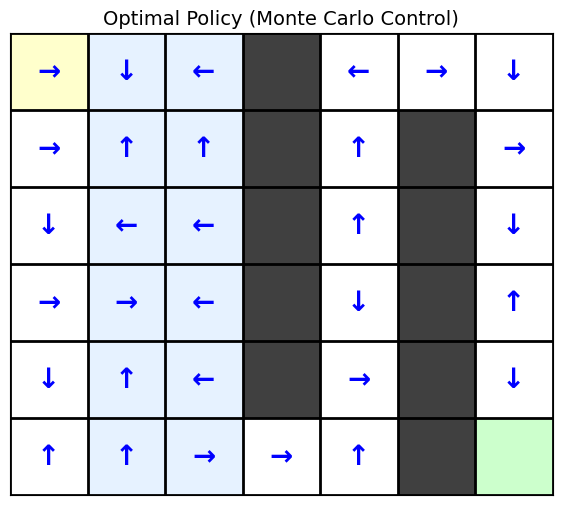

In [36]:
# Convert deterministic policy format back to probability distribution (100%) for plotting
plotable_policy = {}
for state, action in optimal_policy.items():
    plotable_policy[state] = {action: 1.0}
    
plot_policy(env, "Monte Carlo Control", plotable_policy, wind_map=WIND_MAP)

### 2.2 Monte Carlo Control - Path and Performance ep. by ep.
We can visually analyse the learning process of the agent by animating the paths taken by the agent episode after episode. We also plot the total rewards (as average reward per step) per episode and the number of steps per episode over time. These measures should allow us to understand whether the agent was actually able to learn the optimal policy during after the training phase

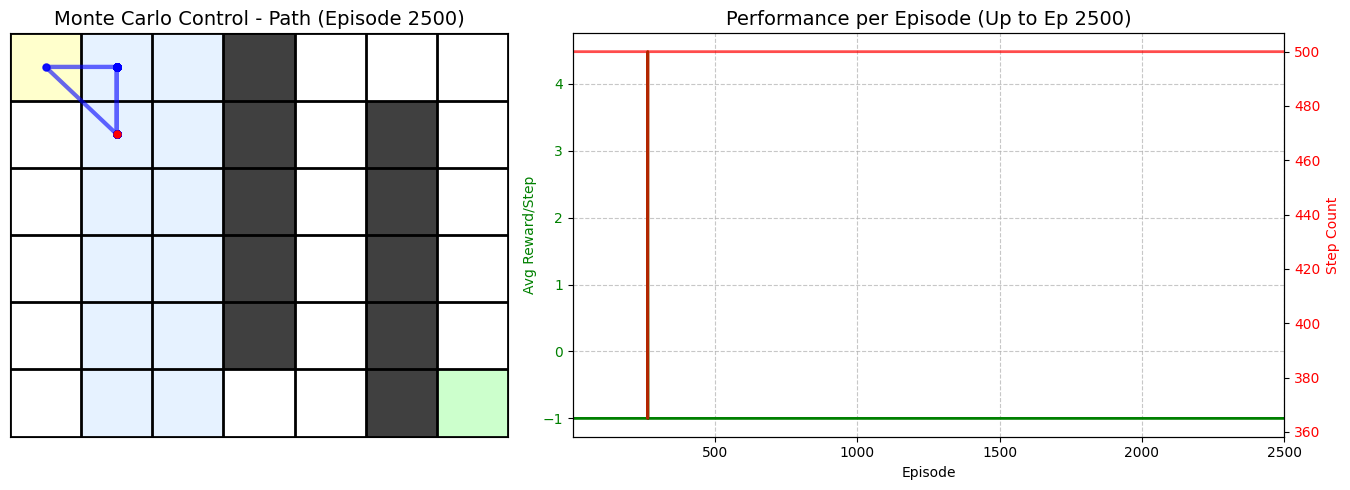

In [37]:
# Configuration variables
step_size = 50  # Skip episodes to speed up animation
total_episodes = len(mc_control.paths)

# Run the visualization loop
for i in range(0, total_episodes, step_size):
    clear_output(wait=True)
    plot_combined_chart(
        env=env, 
        algorithm="Monte Carlo Control", 
        path=mc_control.paths[i], 
        episode=i + 1, 
        rewards_up_to_now=mc_control.episode_rewards[:i+1],
        lengths_up_to_now=mc_control.episode_lengths[:i+1],
        wind_map=WIND_MAP
    )
    time.sleep(0.5)

# Plot the final frame (ensures we see the very last episode)
clear_output(wait=True)
plot_combined_chart(
    env=env, 
    algorithm="Monte Carlo Control", 
    path=mc_control.paths[-1], 
    episode=total_episodes, 
    rewards_up_to_now=mc_control.episode_rewards,
    lengths_up_to_now=mc_control.episode_lengths,
    wind_map=WIND_MAP
)

## 3. SARSA Control
As we did for other algorithms, Monte Carlo is just one of the approaches we can take. One other natural solution is based on temporal differences and it's called SARSA. This name comes from the tuple (state - action - reward - next state - next action) which is the information we are using in SARSA algorithm when updating our $Q(s,a)$ function. The idea is inspired by TD(0): we look ahead one step, gather the reward and observe our next state and action, then we update the $Q(s,a)$ function in that direction via a lerning rate. We are still going to use an *epsilon* parameter for the trade-off between exploration and exploitation and we need to explicitely introduce an *alpha* parameter serving as a learning rate for the singular update.

In [38]:
max_episodes = 2500
ALPHA = 0.1

# 1. Initialize SARSA 
# Notice we added alpha (learning rate), which TD methods like SARSA need:
sarsa_control = SarsaControl(env, gamma=GAMMA, alpha=ALPHA, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995)
# 2. Train SARSA
optimal_policy, Q_values = sarsa_control.train(num_episodes=max_episodes, max_steps=500, verbose=True)

SARSA Control completed 2500 episodes in 0.1296 seconds.
Goal reached 2434 times (97.36%).
Final epsilon: 0.0100


### 3.1 SARSA Control - Optimal Policy

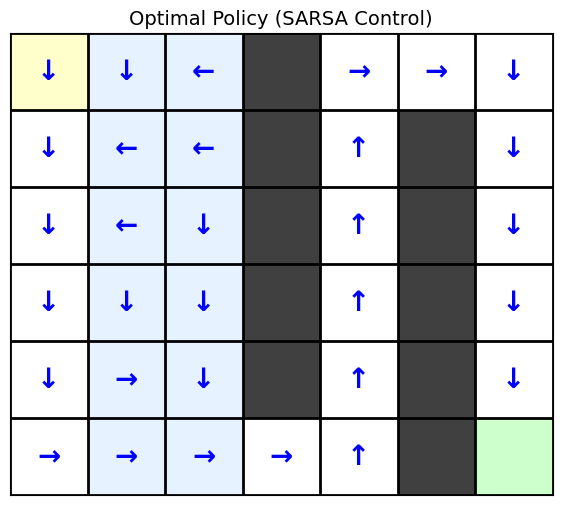

In [39]:
# 3. Convert deterministic policy format back to probability distribution for plotting
plotable_policy = {}
for state, action in optimal_policy.items():
    plotable_policy[state] = {action: 1.0}
    
# 4. Plot the resulting policy
plot_policy(env, "SARSA Control", plotable_policy, wind_map=WIND_MAP)

### 3.2 SARSA Control - Path and Performance ep. by ep.

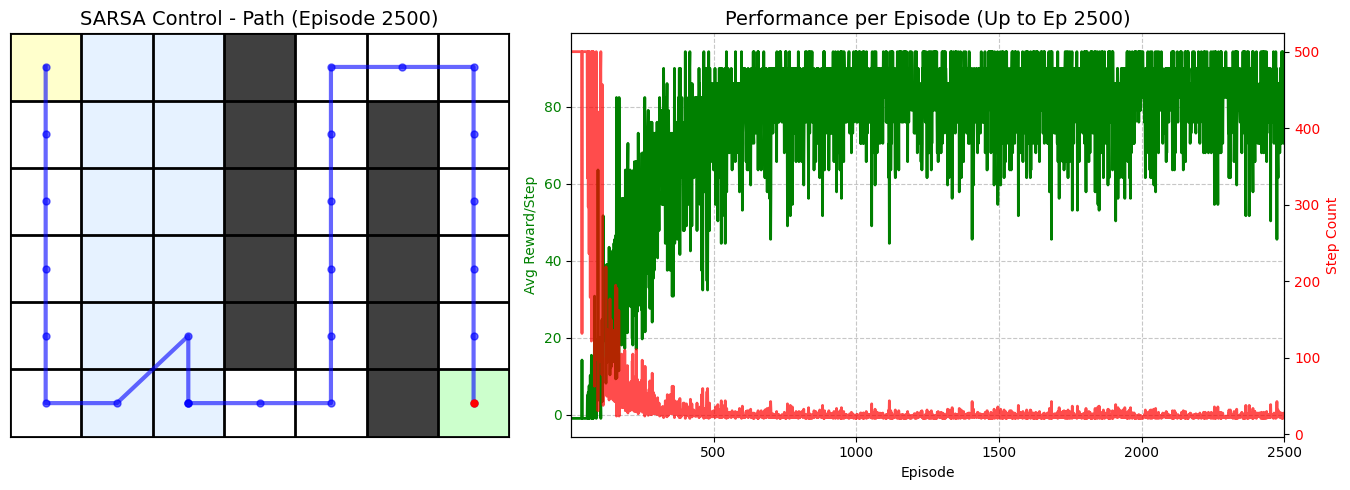

In [40]:
# Configuration variables
step_size = 50  # Skip episodes to speed up animation
total_episodes = len(sarsa_control.paths)
# Run the visualization loop
for i in range(0, total_episodes, step_size):
    clear_output(wait=True)
    plot_combined_chart(
        env=env, 
        algorithm="SARSA Control", 
        path=sarsa_control.paths[i], 
        episode=i + 1, 
        rewards_up_to_now=sarsa_control.episode_rewards[:i+1],
        lengths_up_to_now=sarsa_control.episode_lengths[:i+1],
        wind_map=WIND_MAP
    )
    time.sleep(0.5)
# Plot the final condition frame (ensures we see the very last episode)
clear_output(wait=True)
plot_combined_chart(
    env=env, 
    algorithm="SARSA Control", 
    path=sarsa_control.paths[-1], 
    episode=total_episodes, 
    rewards_up_to_now=sarsa_control.episode_rewards,
    lengths_up_to_now=sarsa_control.episode_lengths,
    wind_map=WIND_MAP
)

## 4. Q-LEARNING
This is the first algorithm following a very different logic: so far we have implemented algorithm applying on-policy strategies that is, they use the policy their own policy to improve the policy itself. Q-Learning instead is an off-policy algorithm which exploits another policy when updating the current policy. In particuar, Q-Learning is targeting a greedy policy, hence it updates the current policy a bit in the direction of the "best" possible action available. In practice, this approach is pretty effective in reaching an optimal solution. We are still using both an *epsilon* parameter governing the trade off between exploration and exploitation, and a *alpha* parameter being the learning rate.

In [41]:
max_episodes = 2500
ALPHA = 0.1

q_learning_control = QLearningControl(env, gamma=GAMMA, alpha=ALPHA, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995)

optimal_policy, Q_values = q_learning_control.train(num_episodes=max_episodes, max_steps=500, verbose=True)

Q-Learning Control completed 2500 episodes in 0.1572 seconds.
Goal reached 2436 times (97.44%).
Final epsilon: 0.0100


### 4.1 Q-Learning - Optimal Policy

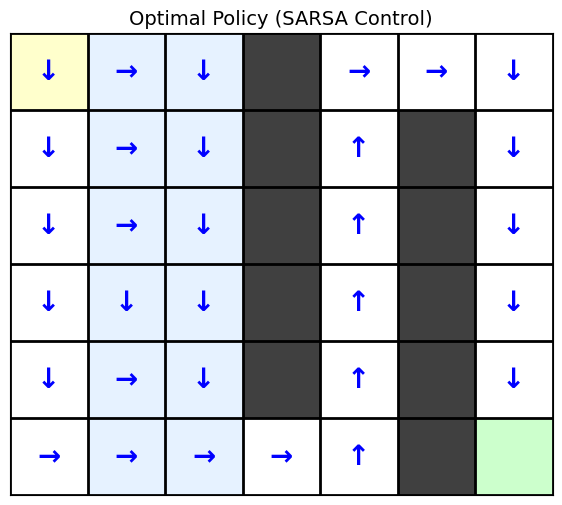

In [42]:
# 3. Convert deterministic policy format back to probability distribution for plotting
plotable_policy = {}
for state, action in optimal_policy.items():
    plotable_policy[state] = {action: 1.0}
    
# 4. Plot the resulting policy
plot_policy(env, "SARSA Control", plotable_policy, wind_map=WIND_MAP)

### 3.2 Q-Learning - Path and Performance ep. by ep.

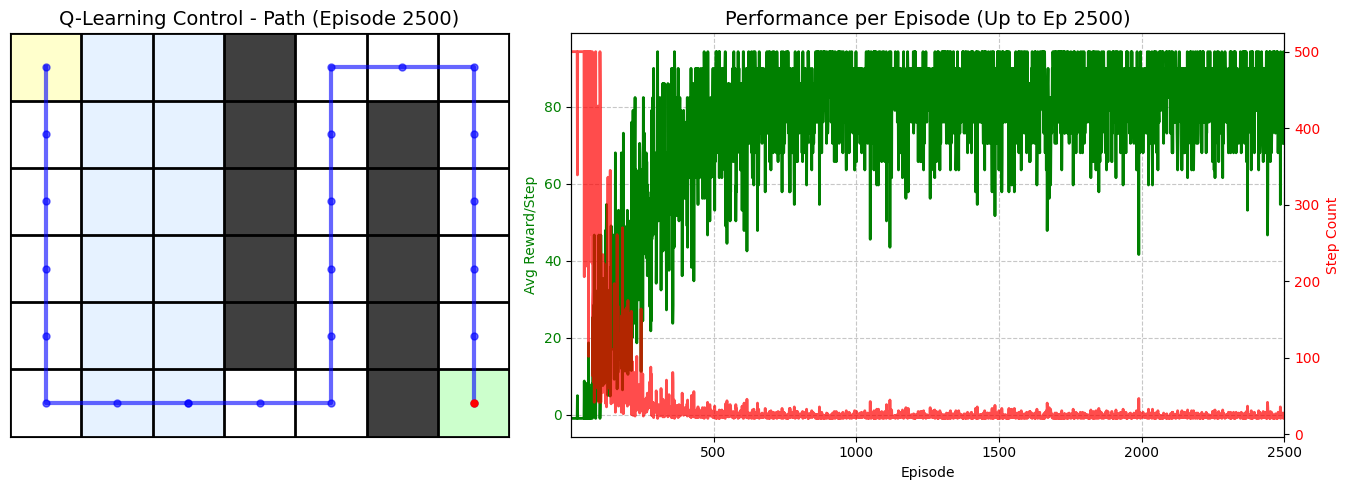

In [43]:
# Configuration variables
step_size = 50  # Skip episodes to speed up animation
total_episodes = len(q_learning_control.paths)
# Run the visualization loop
for i in range(0, total_episodes, step_size):
    clear_output(wait=True)
    plot_combined_chart(
        env=env, 
        algorithm="Q-Learning Control", 
        path=q_learning_control.paths[i], 
        episode=i + 1, 
        rewards_up_to_now=q_learning_control.episode_rewards[:i+1],
        lengths_up_to_now=q_learning_control.episode_lengths[:i+1],
        wind_map=WIND_MAP
    )
    time.sleep(0.5)
# Plot the final condition frame (ensures we see the very last episode)
clear_output(wait=True)
plot_combined_chart(
    env=env, 
    algorithm="Q-Learning Control", 
    path=q_learning_control.paths[-1], 
    episode=total_episodes, 
    rewards_up_to_now=q_learning_control.episode_rewards,
    lengths_up_to_now=q_learning_control.episode_lengths,
    wind_map=WIND_MAP
)